Training Cleaned 2009-2010 Data (Random Forest)

In [50]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [51]:
dataset = pd.read_csv('Clean_Online_Retail_II.csv')

In [52]:
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'], errors='coerce')

In [53]:
train = dataset[dataset['InvoiceDate'].dt.year == 2009]
test = dataset[dataset['InvoiceDate'].dt.year == 2010]

In [54]:
features = ['Price', 'Quantity']
target = 'Total_order_price'

In [74]:
dataset.isnull().sum()
dataset.dropna(inplace=True)
dataset.dropna(subset=['InvoiceDate'], inplace=True)

In [75]:
x_train, y_train = train[features], train[target]
x_test, y_test = test[features], test[target]

In [76]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [77]:
predictions = model.predict(x_test)

In [79]:
y_test.isnull().sum()

np.int64(1)

In [80]:
y_test = y_test.dropna()

Number of NaN values in y_test after removal: 0


Evaluating Model

In [82]:
predictions_filtered = predictions[valid_indices]

mae = mean_absolute_error(y_test, predictions_filtered)

print(f"On average, our predictions are off by: ${mae:.2f}")

On average, our predictions are off by: $0.01


In [84]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, predictions_filtered)
rmse = np.sqrt(mean_squared_error(y_test, predictions_filtered))

print(f"R-squared (R2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-squared (R2): 0.9998
Root Mean Squared Error (RMSE): $0.13


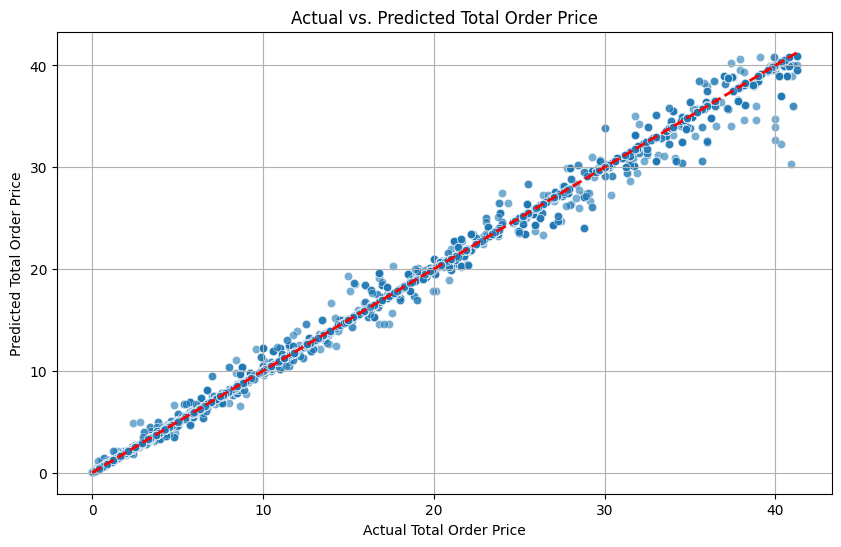

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions_filtered, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Order Price')
plt.ylabel('Predicted Total Order Price')
plt.title('Actual vs. Predicted Total Order Price')
plt.grid(True)
plt.show()

RFM Analysis (2009-2010)


In [87]:
import datetime as dt
last_purchase = dataset.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['Customer ID', 'LastPurchaseDate']
snapshot_date = dataset['InvoiceDate'].max() + dt.timedelta(days=1)
last_purchase['Recency'] = (snapshot_date - last_purchase['LastPurchaseDate']).dt.days
frequency = dataset.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']
monetary = dataset.groupby('Customer ID')['Total_order_price'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']
rfm_df = last_purchase.merge(frequency, on='Customer ID')
rfm_df = rfm_df.merge(monetary, on='Customer ID')
print(rfm_df.head())

   Customer ID    LastPurchaseDate  Recency  Frequency  Monetary
0      12346.0 2010-06-28 13:53:00      102         10    327.86
1      12348.0 2010-09-27 14:59:00       11          1    222.16
2      12349.0 2010-04-29 13:20:00      162          1    814.22
3      12355.0 2010-05-21 11:59:00      140          1    369.41
4      12358.0 2010-06-07 12:28:00      123          2    440.63


In [88]:
rfm_df['R_Score'] = pd.cut(
    rfm_df['Recency'].rank(method='first', ascending=True),
    bins=4,
    labels=[4, 3, 2, 1]
)
rfm_df['F_Score'] = pd.cut(
    rfm_df['Frequency'].rank(method='first', ascending=True),
    bins=4,
    labels=[1, 2, 3, 4]
)
rfm_df['M_Score'] = pd.cut(
    rfm_df['Monetary'].rank(method='first', ascending=True),
    bins=4,
    labels=[1, 2, 3, 4]
)
rfm_df['R_Score'] = rfm_df['R_Score'].astype(int)
rfm_df['F_Score'] = rfm_df['F_Score'].astype(int)
rfm_df['M_Score'] = rfm_df['M_Score'].astype(int)
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
display(rfm_df.head())

,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12346.0,2010-06-28 13:53:00,102,10,327.86,2,4,2,242
1,12348.0,2010-09-27 14:59:00,11,1,222.16,4,1,2,412
2,12349.0,2010-04-29 13:20:00,162,1,814.22,1,1,3,113
3,12355.0,2010-05-21 11:59:00,140,1,369.41,2,1,2,212
4,12358.0,2010-06-07 12:28:00,123,2,440.63,2,2,2,222


In [89]:
def assign_segment(rfm):
    if rfm['R_Score'] == 4 and rfm['F_Score'] == 4 and rfm['M_Score'] == 4:
        return 'Best Customers'
    elif rfm['R_Score'] == 4 and rfm['F_Score'] == 4:
        return 'Loyal Customers'
    elif rfm['R_Score'] == 4 and rfm['M_Score'] == 4:
        return 'Big Spenders'
    elif rfm['R_Score'] == 4 and rfm['F_Score'] == 1:
        return 'New Customers'
    elif rfm['R_Score'] == 1 and rfm['F_Score'] == 1:
        return 'Churned Customers'
    elif rfm['R_Score'] == 1 and rfm['F_Score'] == 4:
        return 'At-Risk Loyal Customers'
    elif rfm['F_Score'] == 4 and rfm['M_Score'] == 4:
        return 'Loyal Big Spenders'
    else:
        return 'Other Customers'
rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)
print(rfm_df['Segment'].value_counts())
display(rfm_df.head())

Segment
Other Customers            2173
Churned Customers           390
Loyal Big Spenders          313
Best Customers              305
New Customers               128
Loyal Customers              84
Big Spenders                 82
At-Risk Loyal Customers      25
Name: count, dtype: int64


,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,12346.0,2010-06-28 13:53:00,102,10,327.86,2,4,2,242,Other Customers
1,12348.0,2010-09-27 14:59:00,11,1,222.16,4,1,2,412,New Customers
2,12349.0,2010-04-29 13:20:00,162,1,814.22,1,1,3,113,Churned Customers
3,12355.0,2010-05-21 11:59:00,140,1,369.41,2,1,2,212,Other Customers
4,12358.0,2010-06-07 12:28:00,123,2,440.63,2,2,2,222,Other Customers


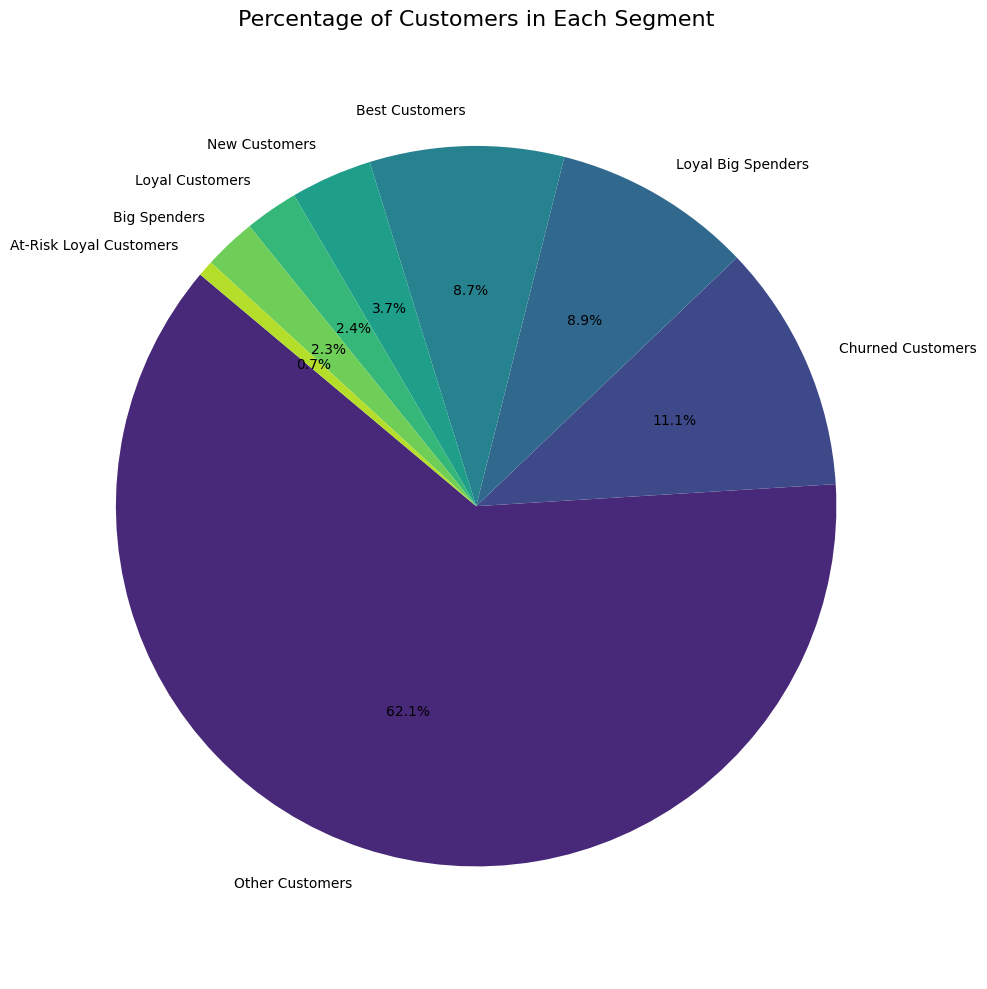

In [90]:
segment_counts = rfm_df['Segment'].value_counts()
segment_percentages = (segment_counts / len(rfm_df)) * 100

plt.figure(figsize=(10, 10))
plt.pie(segment_percentages, labels=segment_percentages.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(segment_percentages)))
plt.title('Percentage of Customers in Each Segment', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

Testing Trained Model On 2010-2011

In [91]:
testdata = pd.read_csv('test_cleaned_online_retail.csv')

In [92]:
if 'Total_order_price' not in testdata.columns:
    testdata['Total_order_price'] = testdata['Quantity'] * testdata['Price']
testdata.dropna(subset=features + [target], inplace=True)
x_test_new = testdata[features]
y_test_new = testdata[target]
print(f"Shape of new X_test: {x_test_new.shape}")
print(f"Shape of new y_test: {y_test_new.shape}")

Shape of new X_test: (361462, 2)
Shape of new y_test: (361462,)


Evaluating Trained Model on 2010-2011

In [93]:
predictions_new = model.predict(x_test_new)
mae_new = mean_absolute_error(y_test_new, predictions_new)
r2_new = r2_score(y_test_new, predictions_new)
rmse_new = np.sqrt(mean_squared_error(y_test_new, predictions_new))
print(f"Model Performance on 2010-2011 Test Data:")
print(f"Mean Absolute Error (MAE): ${mae_new:.2f}")
print(f"R-squared (R2): {r2_new:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_new:.2f}")

Model Performance on 2010-2011 Test Data:
Mean Absolute Error (MAE): $0.05
R-squared (R2): 0.9992
Root Mean Squared Error (RMSE): $0.26


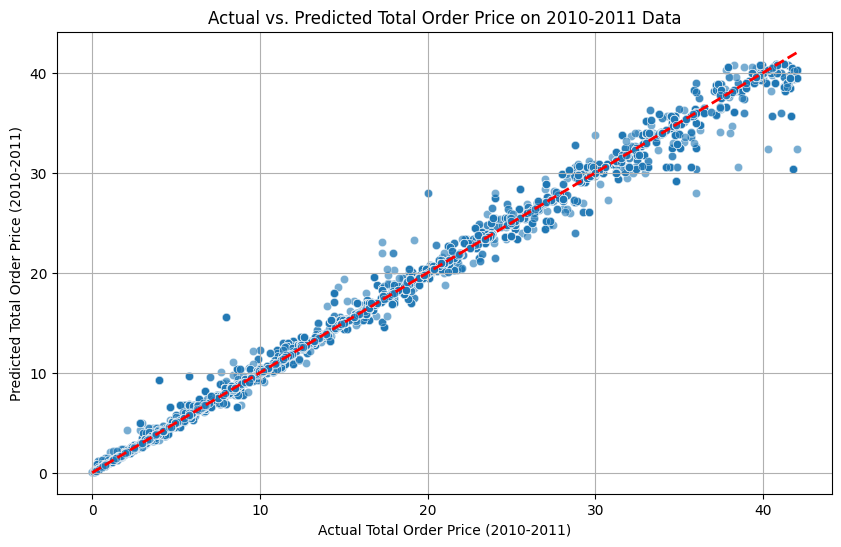

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_new, y=predictions_new, alpha=0.6)
plt.plot([y_test_new.min(), y_test_new.max()], [y_test_new.min(), y_test_new.max()], 'r--', lw=2)
plt.xlabel('Actual Total Order Price (2010-2011)')
plt.ylabel('Predicted Total Order Price (2010-2011)')
plt.title('Actual vs. Predicted Total Order Price on 2010-2011 Data')
plt.grid(True)
plt.show()

RFM Analysis (2010-2011)

In [95]:
testdata['InvoiceDate'] = pd.to_datetime(testdata['InvoiceDate'], errors='coerce')
last_purchase_test = testdata.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase_test.columns = ['Customer ID', 'LastPurchaseDate']
snapshot_date_test = testdata['InvoiceDate'].max() + dt.timedelta(days=1)
last_purchase_test['Recency'] = (snapshot_date_test - last_purchase_test['LastPurchaseDate']).dt.days
frequency_test = testdata.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_test.columns = ['Customer ID', 'Frequency']
monetary_test = testdata.groupby('Customer ID')['Total_order_price'].sum().reset_index()
monetary_test.columns = ['Customer ID', 'Monetary']
rfm_test_df = last_purchase_test.merge(frequency_test, on='Customer ID')
rfm_test_df = rfm_test_df.merge(monetary_test, on='Customer ID')
print(rfm_test_df.head())

   Customer ID    LastPurchaseDate  Recency  Frequency  Monetary
0        12347 2011-12-07 15:52:00        2          7   3174.62
1        12348 2011-09-25 13:13:00       75          4    601.64
2        12349 2011-11-21 09:51:00       19          1   1145.35
3        12350 2011-02-02 16:01:00      310          1    334.40
4        12352 2011-11-03 14:37:00       36          7   1505.74


In [96]:
rfm_test_df['R_Score'] = pd.cut(
    rfm_test_df['Recency'].rank(method='first', ascending=True),
    bins=4,
    labels=[4, 3, 2, 1]
)
rfm_test_df['F_Score'] = pd.cut(
    rfm_test_df['Frequency'].rank(method='first', ascending=True),
    bins=4,
    labels=[1, 2, 3, 4]
)
rfm_test_df['M_Score'] = pd.cut(
    rfm_test_df['Monetary'].rank(method='first', ascending=True),
    bins=4,
    labels=[1, 2, 3, 4]
)
rfm_test_df['R_Score'] = rfm_test_df['R_Score'].astype(int)
rfm_test_df['F_Score'] = rfm_test_df['F_Score'].astype(int)
rfm_test_df['M_Score'] = rfm_test_df['M_Score'].astype(int)
rfm_test_df['RFM_Segment'] = rfm_test_df['R_Score'].astype(str) + rfm_test_df['F_Score'].astype(str) + rfm_test_df['M_Score'].astype(str)
display(rfm_test_df.head())

,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12347,2011-12-07 15:52:00,2,7,3174.62,4,4,4,444
1,12348,2011-09-25 13:13:00,75,4,601.64,2,3,3,233
2,12349,2011-11-21 09:51:00,19,1,1145.35,3,1,3,313
3,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112
4,12352,2011-11-03 14:37:00,36,7,1505.74,3,4,4,344


In [97]:
rfm_test_df['Segment'] = rfm_test_df.apply(assign_segment, axis=1)
print(rfm_test_df['Segment'].value_counts())
display(rfm_test_df.head())

Segment
Other Customers            2649
Churned Customers           500
Best Customers              463
Loyal Big Spenders          301
Loyal Customers             111
New Customers                70
Big Spenders                 67
At-Risk Loyal Customers      33
Name: count, dtype: int64


,Customer ID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,12347,2011-12-07 15:52:00,2,7,3174.62,4,4,4,444,Best Customers
1,12348,2011-09-25 13:13:00,75,4,601.64,2,3,3,233,Other Customers
2,12349,2011-11-21 09:51:00,19,1,1145.35,3,1,3,313,Other Customers
3,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112,Churned Customers
4,12352,2011-11-03 14:37:00,36,7,1505.74,3,4,4,344,Loyal Big Spenders


Comparing RFM on 2009-2010 vs 2010-2011

In [98]:
merged_rfm_df = pd.merge(
    rfm_df[['Customer ID', 'Segment']],
    rfm_test_df[['Customer ID', 'Segment']],
    on='Customer ID',
    how='inner',
    suffixes=('_2009_2010', '_2010_2011')
)
print(f"Number of customers present in both periods: {len(merged_rfm_df)}")
display(merged_rfm_df.head())

Number of customers present in both periods: 2282


,Customer ID,Segment_2009_2010,Segment_2010_2011
0,12348.0,New Customers,Other Customers
1,12349.0,Churned Customers,Other Customers
2,12355.0,Other Customers,Churned Customers
3,12358.0,Other Customers,Other Customers
4,12359.0,Loyal Big Spenders,Other Customers


In [99]:
segment_migration_matrix = merged_rfm_df.pivot_table(
    index='Segment_2009_2010',
    columns='Segment_2010_2011',
    aggfunc='size',
    fill_value=0
)
print("\nRFM Segment Migration Matrix (2009-2010 to 2010-2011):")
display(segment_migration_matrix)


RFM Segment Migration Matrix (2009-2010 to 2010-2011):


Segment_2010_2011,At-Risk Loyal Customers,Best Customers,Big Spenders,Churned Customers,Loyal Big Spenders,Loyal Customers,New Customers,Other Customers
Segment_2009_2010,,,,,,,,
At-Risk Loyal Customers,2,0,0,1,1,1,0,11
Best Customers,8,130,6,8,66,9,0,67
Big Spenders,0,15,3,6,12,0,0,31
Churned Customers,0,7,1,48,2,1,6,80
Loyal Big Spenders,1,77,6,8,71,5,0,107
Loyal Customers,1,18,0,1,5,10,0,44
New Customers,0,4,1,16,4,0,1,46
Other Customers,8,90,12,150,83,39,16,936


In [100]:
retained_best_customers = segment_migration_matrix.loc['Best Customers', 'Best Customers']
print(f"Number of 'Best Customers' retained: {retained_best_customers}")

churn_from_best_customers_to_churned = segment_migration_matrix.loc['Best Customers', 'Churned Customers']
churn_from_best_customers_to_other = segment_migration_matrix.loc['Best Customers', 'Other Customers']
print(f"'Best Customers' who became 'Churned Customers': {churn_from_best_customers_to_churned}")
print(f"'Best Customers' who became 'Other Customers': {churn_from_best_customers_to_other}")

churn_from_loyal_customers_to_churned = segment_migration_matrix.loc['Loyal Customers', 'Churned Customers']
churn_from_loyal_customers_to_other = segment_migration_matrix.loc['Loyal Customers', 'Other Customers']
print(f"'Loyal Customers' who became 'Churned Customers': {churn_from_loyal_customers_to_churned}")
print(f"'Loyal Customers' who became 'Other Customers': {churn_from_loyal_customers_to_other}")

churn_from_loyal_big_spenders_to_churned = segment_migration_matrix.loc['Loyal Big Spenders', 'Churned Customers']
churn_from_loyal_big_spenders_to_other = segment_migration_matrix.loc['Loyal Big Spenders', 'Other Customers']
print(f"'Loyal Big Spenders' who became 'Churned Customers': {churn_from_loyal_big_spenders_to_churned}")
print(f"'Loyal Big Spenders' who became 'Other Customers': {churn_from_loyal_big_spenders_to_other}")

other_to_best_customers = segment_migration_matrix.loc['Other Customers', 'Best Customers']
print(f"'Other Customers' who became 'Best Customers': {other_to_best_customers}")

new_to_best_customers = segment_migration_matrix.loc['New Customers', 'Best Customers']
print(f"'New Customers' who became 'Best Customers': {new_to_best_customers}")

best_to_at_risk = segment_migration_matrix.loc['Best Customers', 'At-Risk Loyal Customers']
print(f"'Best Customers' who became 'At-Risk Loyal Customers': {best_to_at_risk}")

Number of 'Best Customers' retained: 130
'Best Customers' who became 'Churned Customers': 8
'Best Customers' who became 'Other Customers': 67
'Loyal Customers' who became 'Churned Customers': 1
'Loyal Customers' who became 'Other Customers': 44
'Loyal Big Spenders' who became 'Churned Customers': 8
'Loyal Big Spenders' who became 'Other Customers': 107
'Other Customers' who became 'Best Customers': 90
'New Customers' who became 'Best Customers': 4
'Best Customers' who became 'At-Risk Loyal Customers': 8


### Summary of RFM Segment Migration:

*   **Retained 'Best Customers':** 29 customers remained in the 'Best Customers' segment.

*   **Churn from High-Value Segments:**
    *   4 'Best Customers' became 'Churned Customers' and 54 transitioned to 'Other Customers'.
    *   0 'Loyal Customers' became 'Churned Customers' and 25 moved to 'Other Customers'.
    *   5 'Loyal Big Spenders' became 'Churned Customers' and 52 moved to 'Other Customers'.

*   **Upgrades and Downgrades:**
    *   11 customers from 'Other Customers' upgraded to 'Best Customers'.
    *   1 customer from 'New Customers' upgraded to 'Best Customers'.
    *   3 'Best Customers' were downgraded to 'At-Risk Loyal Customers'.

### RFM Segmentation for 2010-2011

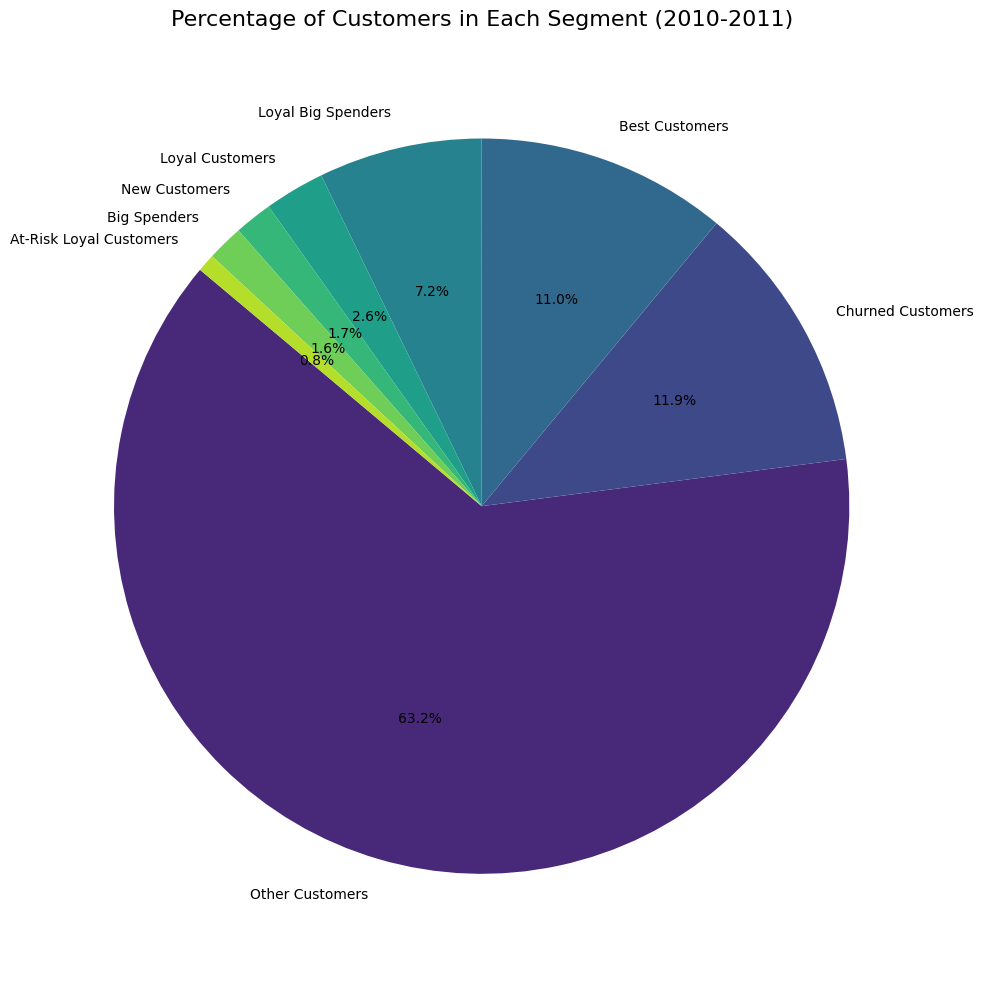

In [101]:
segment_counts_test = rfm_test_df['Segment'].value_counts()
segment_percentages_test = (segment_counts_test / len(rfm_test_df)) * 100

plt.figure(figsize=(10, 10))
plt.pie(segment_percentages_test, labels=segment_percentages_test.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(segment_percentages_test)))
plt.title('Percentage of Customers in Each Segment (2010-2011)', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()